# Programa de Capacitação de Processamento Digital de Sinais

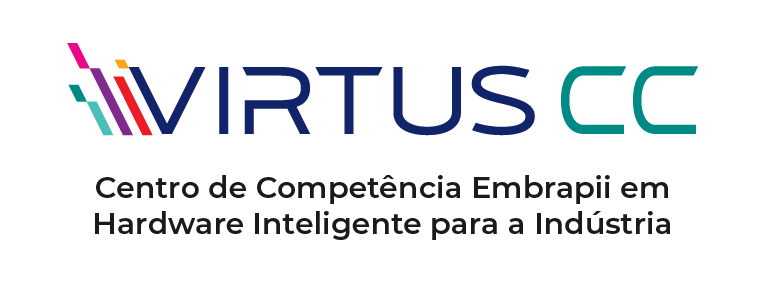


### Desenvolvido por:
-   Elmer Pimentel Farias



### Capítulos 4, 5 e 6 — Filtros Digitais  
**Baseado no livro “Processamento Digital de Sinais” — Paulo S. R. Diniz**

---

## Capítulo 4 — Filtros Digitais
O Capítulo 4 apresenta os fundamentos dos **filtros digitais**, dispositivos utilizados para modificar o espectro de um sinal de acordo com critérios de frequência.

São discutidos:
- As classificações: **passa-baixas**, **passa-altas**, **passa-faixa** e **rejeita-faixa**;  
- As diferenças entre filtros de **resposta ao impulso finita (FIR)** e **resposta ao impulso infinita (IIR)**;  
- A representação em **domínio Z**, o **diagrama de polos e zeros** e a **resposta em frequência**.

---

## Capítulo 5 — Filtros FIR
Os filtros **FIR (Finite Impulse Response)** possuem resposta ao impulso de duração finita, garantindo **estabilidade incondicional** e **fase linear**.

O capítulo enfatiza o **método de projeto por janelamento**, em especial o uso da **janela de Hamming**, que permite controlar a largura de banda e a atenuação do filtro.  
A análise da **resposta em frequência** e da **fase** é essencial para avaliar o desempenho e a seletividade do filtro.

---

## Capítulo 6 — Filtros IIR
Os filtros **IIR (Infinite Impulse Response)** são caracterizados pela **realimentação**, o que proporciona maior eficiência e seletividade espectral.  
Contudo, exigem cuidado com a **estabilidade** e a **linearidade de fase**.

São estudados os principais tipos:
- **Butterworth:** resposta suave e monotônica;  
- **Chebyshev:** maior seletividade à custa de ondulações na banda passante;  
- **Elíptico:** alta seletividade, porém com ondulações em ambas as bandas.

---

## Objetivos da Capacitação

1. **Projetar e aplicar** um **filtro FIR passa-baixas** utilizando a **janela de Hamming** em sinais ruidosos, comparando os sinais de entrada e saída.  
2. **Projetar e aplicar** um **filtro IIR Butterworth passa-altas** em sinais ruidosos, comparando os sinais de entrada e saída.  
3. **Analisar** a **resposta em frequência e fase** dos filtros projetados, avaliando suas características e desempenho.

---

*Capítulos 4, 5 e 6 — Livro “Processamento Digital de Sinais”, Paulo S. R. Diniz.*


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal
from numba import njit, jit , vectorize , prange
import cupy as cp
import cupyx

In [11]:
@njit(parallel=True)
def low_pass(N, fc, fs):
    """
    Calcula os coeficientes h[n] de um filtro FIR passa-baixa ideal
    usando um laço 'for' explícito.

    Argumentos:
    N (int): Ordem do filtro (número de coeficientes).
    fc (float): Frequência de corte (em Hertz).
    fs (float): Frequência de amostragem (em Hertz).

    Retorna:
    numpy.ndarray: Vetor de coeficientes h[n] do filtro.
    """
    
    # 1. CONVERSÃO: Calcula a frequência de corte digital (rad/amostra)
    #    a partir das frequências em Hertz.
    wc = 2 * np.pi * (fc / fs)
    
    # 2. Aloca um vetor 'h' vazio (cheio de zeros)
    h = np.zeros(N)
    
    # 3. Calcula o ponto médio (atraso)
    M = (N - 1) / 2
    
    # 4. Itera por cada índice 'n' do filtro
    for n in prange(N):
        # 5. Calcula o eixo 'n' centrado
        n_desloc = n - M
        
        # 6. Trata o caso especial (n = M)
        # Se n_shifted == 0, o limite é wc/pi
        if n_desloc == 0:
            h[n] = wc / np.pi
        else:
            # 7. Calcula todos os outros valores
            # Fórmula: sin(wc * n_desloc) / (pi * n_desloc)
            h[n] = np.sin(wc * n_desloc) / (np.pi * n_desloc)

    return h

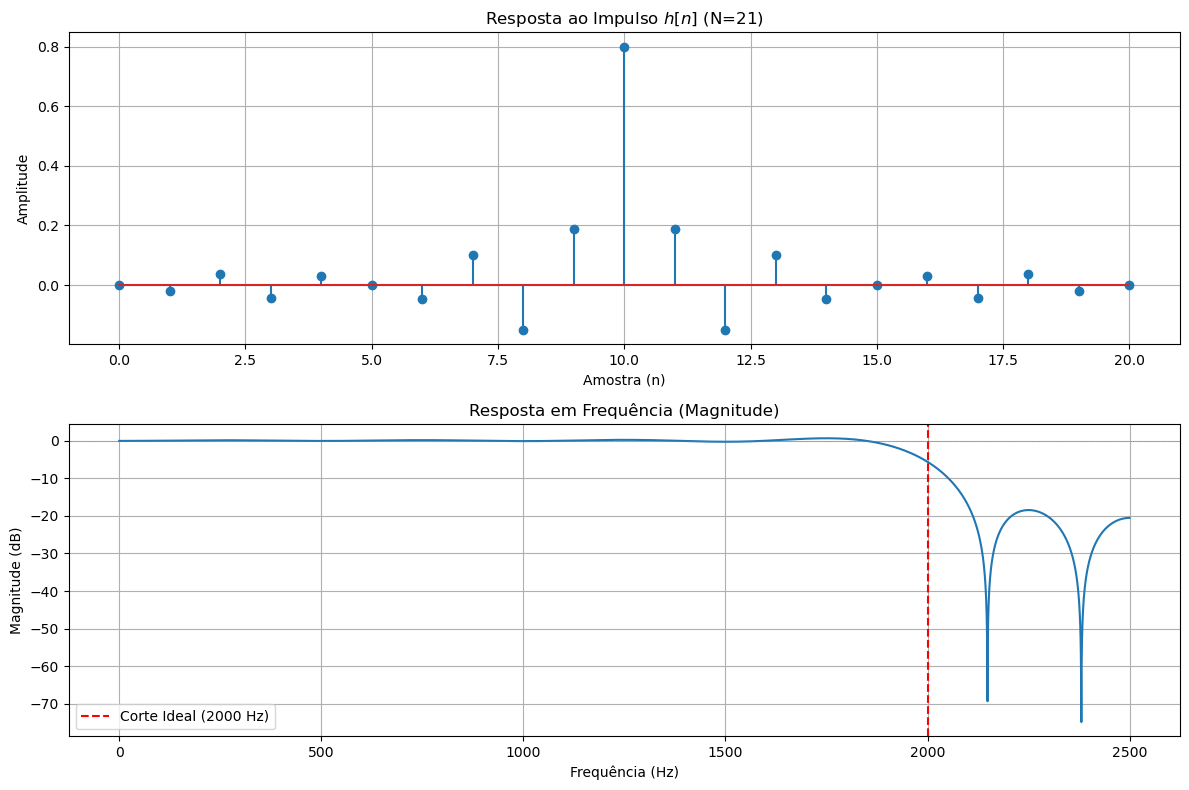

In [ ]:
# Parâmetros do Filtro
N = 21           # Ordem do filtro (número de coeficientes)
fs = 5000        # Frequência de amostragem (Hz) - para exemplo
fc = 2000        # Frequência de corte (Hz)

# 1. Converter frequência de corte (fc) para radianos/amostra (wc)
#    wc = 2 * pi * (fc / fs)
wc = 2 * np.pi * (fc / fs)

# 2. Gerar os coeficientes do filtro
h = low_pass(N,fc,fs)

# 3. Calcular a resposta em frequência do filtro
w, H = freqz(h, worN=8000)

# 4. Plotar os resultados

# Plot da Resposta ao Impulso (h[n])
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.stem(np.arange(N), h)
plt.title(f'Resposta ao Impulso $h[n]$ (N={N})')
plt.xlabel('Amostra (n)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot da Resposta em Frequência (Magnitude)
plt.subplot(2, 1, 2)
# Converter radianos/amostra (w) para Hz
f_hz = (w / (2 * np.pi)) * fs
plt.plot(f_hz, 20 * np.log10(np.abs(H)))
plt.axvline(fc, color='red', linestyle='--', label=f'Corte Ideal ({fc} Hz)')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.5)
plt.title('Resposta em Frequência (Magnitude)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()